In [3]:
import pandas as pd
import numpy as np
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

folder_path = r"C:\Users\ULTRA\Desktop\ML_DATASET" 
us_df = pd.read_csv(os.path.join(folder_path, "USvideos.csv"))
gb_df = pd.read_csv(os.path.join(folder_path, "GBvideos.csv"))
in_df = pd.read_csv(os.path.join(folder_path, "INvideos.csv"))
us_df['country'] = 'US'
gb_df['country'] = 'GB'
in_df['country'] = 'IN'
print("\n US videos shape:", us_df.shape)
print(" GB videos shape:", gb_df.shape)
print(" IN videos shape:", in_df.shape)
df = pd.concat([us_df, gb_df, in_df], ignore_index=True)
print(f"\n Final DataFrame shape: {df.shape}")
print(f" Total videos: {len(df)}")
print(f"\n First 5 rows:")
print(df.head())
print(f"\n Columns in our data:")
print(df.columns.tolist())
df.to_csv(os.path.join(folder_path, "merged_data.csv"), index=False)
print("\n Saved merged_data.csv")


 US videos shape: (40949, 17)
 GB videos shape: (38916, 17)
 IN videos shape: (37352, 17)

 Final DataFrame shape: (117217, 17)
 Total videos: 117217

 First 5 rows:
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:

In [4]:
import json
import os

with open(os.path.join(folder_path, "US_category_id.json"), "r", encoding="utf-8") as f:
    us_data = json.load(f)

with open(os.path.join(folder_path, "GB_category_id.json"), "r", encoding="utf-8") as f:
    gb_data = json.load(f)

with open(os.path.join(folder_path, "IN_category_id.json"), "r", encoding="utf-8") as f:
    in_data = json.load(f)


us_map = {int(i['id']): i['snippet']['title'] for i in us_data['items']}
gb_map = {int(i['id']): i['snippet']['title'] for i in gb_data['items']}
in_map = {int(i['id']): i['snippet']['title'] for i in in_data['items']}


def category_name(row):

    if row['country'] == 'US':
        return us_map.get(row['category_id'], 'Unknown')

    elif row['country'] == 'GB':
        return gb_map.get(row['category_id'], 'Unknown')

    elif row['country'] == 'IN':
        return in_map.get(row['category_id'], 'Unknown')

    else:
        return 'Unknown'

df['category_name'] = df.apply(category_name, axis=1)


print(df[['country', 'category_id', 'category_name']].head())


df.to_csv(os.path.join(folder_path, "data_with_categories.csv"), index=False)

  country  category_id   category_name
0      US           22  People & Blogs
1      US           24   Entertainment
2      US           23          Comedy
3      US           24   Entertainment
4      US           24   Entertainment


# Data Cleaning

In [5]:


df = df.drop_duplicates(subset=['video_id'], keep='first')


important_cols = ['views', 'likes', 'dislikes', 'comment_count']
df = df.dropna(subset=important_cols)


df['tags'] = df['tags'].fillna('')
df['title'] = df['title'].fillna('')
df['channel_title'] = df['channel_title'].fillna('Unknown')


df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')


for col in important_cols:
    df = df[df[col] >= 0]

views_99 = df['views'].quantile(0.99)
likes_99 = df['likes'].quantile(0.99)
df = df[df['views'] <= views_99]
df = df[df['likes'] <= likes_99]


df.to_csv(os.path.join(folder_path, "cleaned_data.csv"), index=False)

print(f"After Cleaning: {len(df)} video ")
print(f"   US: {len(df[df['country']=='US'])} | GB: {len(df[df['country']=='GB'])} | IN: {len(df[df['country']=='IN'])}")

After Cleaning: 24297 video 
   US: 6182 | GB: 2162 | IN: 15953


# Feature Engineering

In [6]:


df['engagement_ratio'] = (
    df['likes'] + df['comment_count']
) / (df['views'] + 1)

df['total_engagement'] = (
    df['likes'] +
    df['comment_count'] +
    df['dislikes']
)

df['tags_count'] = df['tags'].apply(
    lambda x: len(str(x).split('|'))
)
df['title_length'] = df['title'].str.len()

df['publish_hour'] = df['publish_time'].dt.hour

df['has_hashtag'] = df['title'].str.contains('#').astype(int)

df.to_csv(
    os.path.join(folder_path, "data_with_features.csv"),
    index=False
)

print("Done")

Done


# EDA

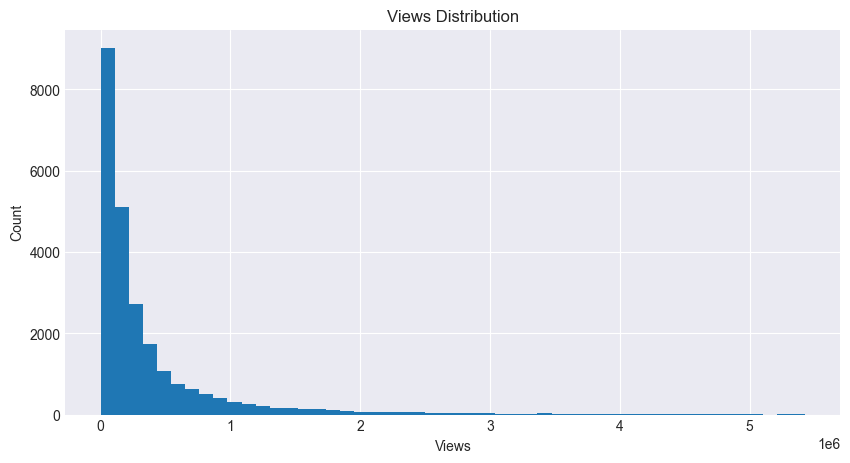

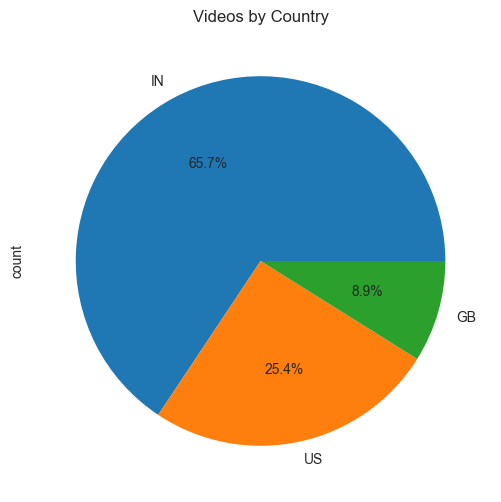

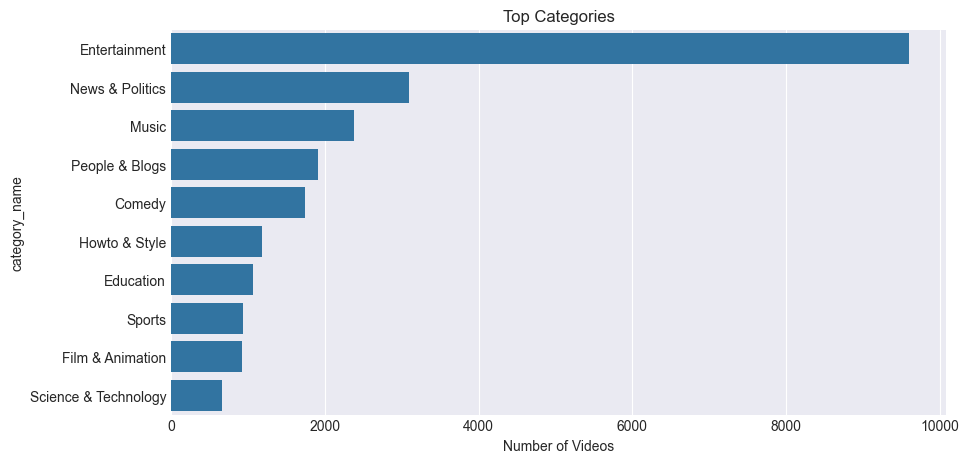

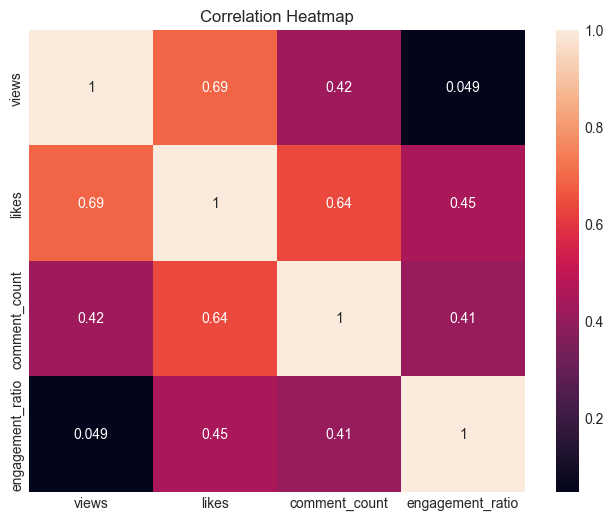

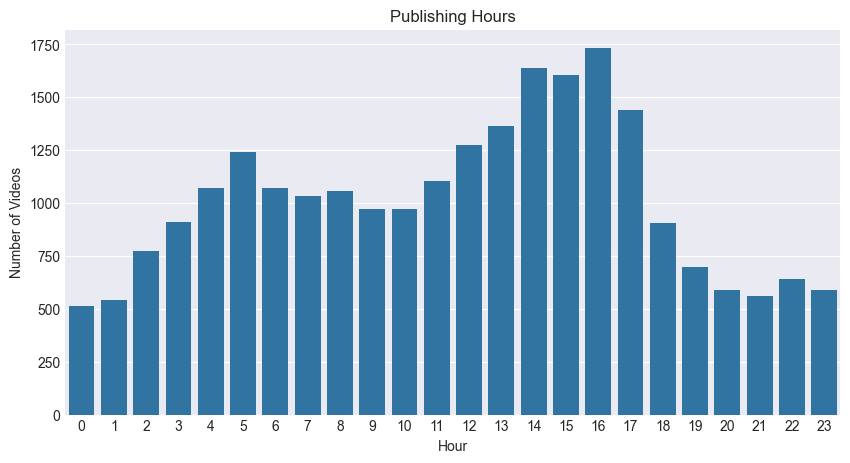

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10,5))

plt.hist(df['views'], bins=50)

plt.title('Views Distribution')
plt.xlabel('Views')
plt.ylabel('Count')

plt.show()


plt.figure(figsize=(6,6))

df['country'].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title('Videos by Country')

plt.show()

plt.figure(figsize=(10,5))

top_categories = df['category_name'].value_counts().head(10)

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title('Top Categories')
plt.xlabel('Number of Videos')

plt.show()

plt.figure(figsize=(8,6))

columns = [
    'views',
    'likes',
    'comment_count',
    'engagement_ratio'
]

sns.heatmap(
    df[columns].corr(),
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

plt.figure(figsize=(10,5))

hours = df['publish_hour'].value_counts().sort_index()

sns.barplot(
    x=hours.index,
    y=hours.values
)

plt.title('Publishing Hours')
plt.xlabel('Hour')
plt.ylabel('Number of Videos')

plt.show()



# Data Preparation for Models


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


features = [
    'views',
    'likes',
    'comment_count'
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_scaled.shape)
print(X_pca.shape)


(24297, 3)
(24297, 2)


In [9]:
np.save(os.path.join(folder_path, "X_scaled.npy"), X_scaled)
df.to_csv(
    os.path.join(folder_path, "final_data.csv"),
    index=False
)

print("success save")

success save


#  Classical Clustering

In [10]:
folder_path = r"C:\Users\ULTRA\Desktop\ML_DATASET"

X_scaled = np.load(os.path.join(folder_path, "X_scaled.npy"))

df = pd.read_csv(os.path.join(folder_path, "final_data.csv"))

print(f" Loaded {X_scaled.shape[0]} videos")
print(f" Number of features: {X_scaled.shape[1]}")
print("="*50)

 Loaded 24297 videos
 Number of features: 3


#  KMEANS CLUSTERING

KMEANS CLUSTERING
k=2: Inertia=38211, Silhouette=0.8263
k=3: Inertia=28063, Silhouette=0.7349
k=4: Inertia=20932, Silhouette=0.7290
k=5: Inertia=17578, Silhouette=0.6851
k=6: Inertia=14910, Silhouette=0.6494
k=7: Inertia=12854, Silhouette=0.6501
k=8: Inertia=11593, Silhouette=0.6062
k=9: Inertia=10428, Silhouette=0.5597
k=10: Inertia=9545, Silhouette=0.5757

Best k = 2 (Silhouette = 0.8263)
Cluster distribution:
kmeans_cluster
0    22908
1     1389
Name: count, dtype: int64


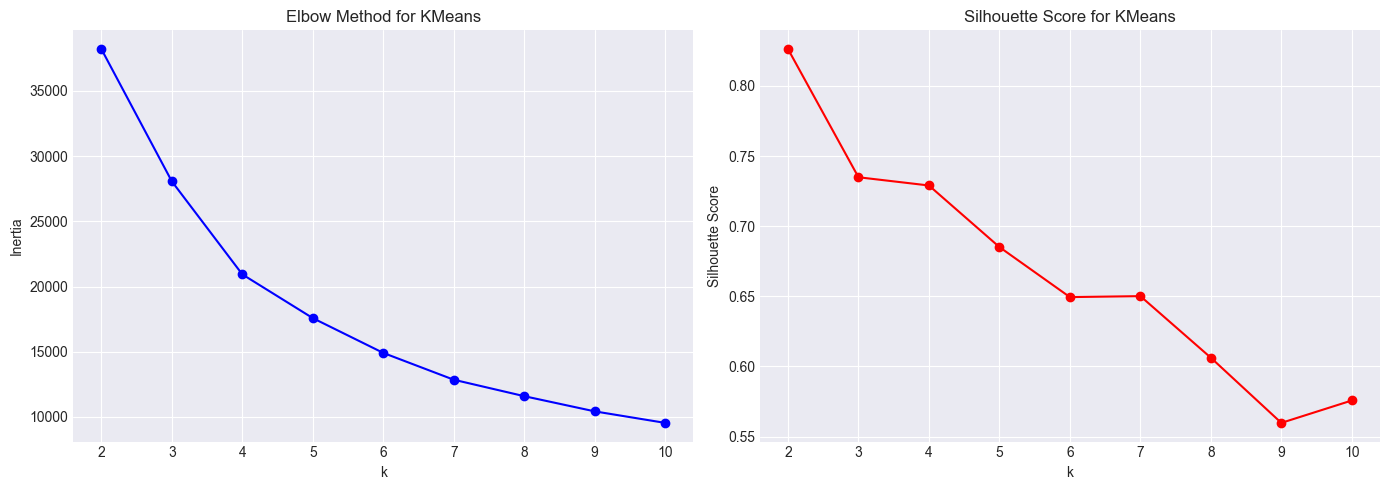

In [11]:
print("KMEANS CLUSTERING")

k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={silhouettes[-1]:.4f}")


best_k = k_values[np.argmax(silhouettes)]
print(f"\nBest k = {best_k} (Silhouette = {max(silhouettes):.4f})")

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = final_kmeans.fit_predict(X_scaled)

print(f"Cluster distribution:")
print(df['kmeans_cluster'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for KMeans')
axes[0].grid(True)

axes[1].plot(k_values, silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for KMeans')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "kmeans_plots.png"), dpi=150, bbox_inches='tight')
plt.show()

#  GMM CLUSTERING

GMM CLUSTERING
n=2: BIC=-671
n=3: BIC=-43245
n=4: BIC=-64331
n=5: BIC=-73295
n=6: BIC=-76539
n=7: BIC=-78240


c:\Users\ULTRA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


n=8: BIC=-83014


c:\Users\ULTRA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


n=9: BIC=-84836


c:\Users\ULTRA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


n=10: BIC=-85724

Best n = 10 (Lowest BIC = -85724)


c:\Users\ULTRA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Cluster distribution:
gmm_cluster
0    4200
1    1588
2    2385
3      46
4    3008
5    4940
6     972
7    4751
8    1903
9     504
Name: count, dtype: int64


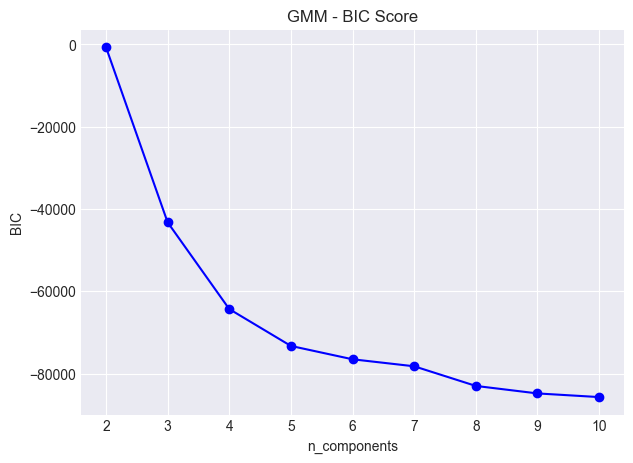

In [12]:
print("GMM CLUSTERING")

n_range = range(2, 11)
bic_scores = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)

    bic_scores.append(gmm.bic(X_scaled))

    print(f"n={n}: BIC={bic_scores[-1]:.0f}")

best_n = n_range[np.argmin(bic_scores)]
print(f"\nBest n = {best_n} (Lowest BIC = {min(bic_scores):.0f})")

final_gmm = GaussianMixture(n_components=best_n, random_state=42)
df['gmm_cluster'] = final_gmm.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['gmm_cluster'].value_counts().sort_index())

plt.figure(figsize=(7,5))
plt.plot(n_range, bic_scores, 'bo-')
plt.xlabel('n_components')
plt.ylabel('BIC')
plt.title('GMM - BIC Score')
plt.grid(True)

plt.savefig(os.path.join(folder_path, "gmm_bic.png"), dpi=150, bbox_inches='tight')
plt.show()

# DBSCAN

 DBSCAN - ANOMALY DETECTION
eps=0.3: 16 clusters, 990 noise (4.1%)
eps=0.5: 9 clusters, 470 noise (1.9%)
eps=0.7: 8 clusters, 242 noise (1.0%)
eps=1.0: 4 clusters, 97 noise (0.4%)
eps=1.2: 1 clusters, 62 noise (0.3%)
eps=1.5: 1 clusters, 48 noise (0.2%)

 best eps = 0.7

 outliers:  242 (1.00%)


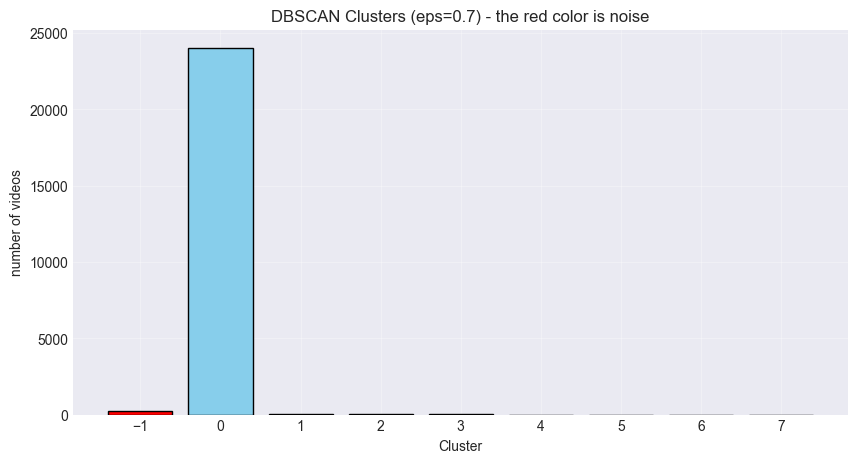

In [13]:
print(" DBSCAN - ANOMALY DETECTION")

eps_values = [0.3, 0.5, 0.7, 1.0, 1.2, 1.5]
results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = sum(labels == -1)
    noise_ratio = n_noise / len(labels) * 100
    
    results.append({'eps': eps, 'clusters': n_clusters, 'noise': n_noise, 'noise_ratio': noise_ratio})
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise ({noise_ratio:.1f}%)")

best_eps = 0.7 
if best_eps not in eps_values:
    best_eps = eps_values[2]

print(f"\n best eps = {best_eps}")

dbscan = DBSCAN(eps=best_eps, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
df['is_anomaly'] = (df['dbscan_cluster'] == -1).astype(int)

anomaly_count = df['is_anomaly'].sum()
print(f"\n outliers:  {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")

plt.figure(figsize=(10, 5))
cluster_counts = df['dbscan_cluster'].value_counts()
colors = ['red' if c == -1 else 'skyblue' for c in cluster_counts.index]
plt.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('number of videos')
plt.title(f'DBSCAN Clusters (eps={best_eps}) - the red color is noise')
plt.xticks(cluster_counts.index)
plt.grid(True, alpha=0.3)
plt.show()

# Compare the results

Model Comparison
KMeans  : 0.8263
GMM     : 0.0469
DBSCAN  : 0.7850

DBSCAN Anomalies: 1.0%

Best Parameters:
KMeans -> k=2
GMM    -> n=10
DBSCAN -> eps=0.7


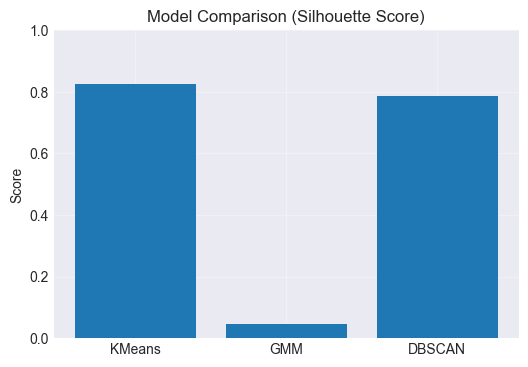

In [14]:
print("Model Comparison")

sil_kmeans = silhouette_score(X_scaled, df['kmeans_cluster'])
sil_gmm = silhouette_score(X_scaled, df['gmm_cluster'])

non_noise = df['dbscan_cluster'] != -1
sil_dbscan = silhouette_score(X_scaled[non_noise], df.loc[non_noise, 'dbscan_cluster'])

print(f"KMeans  : {sil_kmeans:.4f}")
print(f"GMM     : {sil_gmm:.4f}")
print(f"DBSCAN  : {sil_dbscan:.4f}")


anomaly_ratio = df['is_anomaly'].mean() * 100
print(f"\nDBSCAN Anomalies: {anomaly_ratio:.1f}%")

print("\nBest Parameters:")
print(f"KMeans -> k={best_k}")
print(f"GMM    -> n={best_n}")
print(f"DBSCAN -> eps={best_eps}")


plt.figure(figsize=(6,4))
models = ['KMeans', 'GMM', 'DBSCAN']
scores = [sil_kmeans, sil_gmm, sil_dbscan]

plt.bar(models, scores)
plt.title("Model Comparison (Silhouette Score)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.show()

# Cluster Analysis

Cluster Analysis
                    views    likes  comment_count
kmeans_cluster                                   
0                275664.0   6441.0          733.0
1               2154729.0  99237.0        12394.0


<Figure size 1000x500 with 0 Axes>

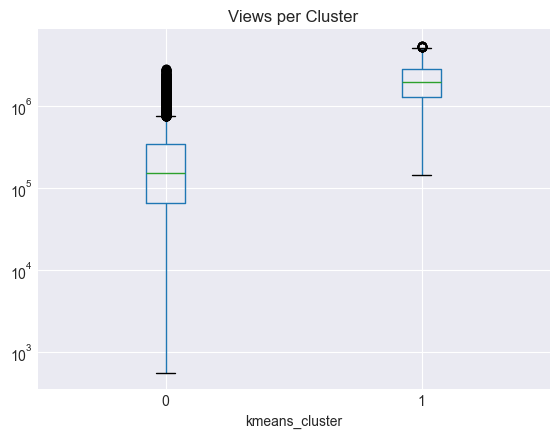

In [15]:
print("Cluster Analysis")

cluster_analysis = df.groupby('kmeans_cluster').agg({
    'views': 'mean',
    'likes': 'mean',
    'comment_count': 'mean'
}).round(0)

print(cluster_analysis)

plt.figure(figsize=(10,5))
df.boxplot(column='views', by='kmeans_cluster')
plt.yscale('log')
plt.title('Views per Cluster')
plt.suptitle('')
plt.show()

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Load Data with Feature

In [17]:
X = np.load(r"C:/Users/ULTRA\Desktop/ML_DATASET/X_scaled.npy")
print(f"X shape: {X.shape}")  # (24297, 3)

X_tensor = torch.tensor(X, dtype=torch.float32)

X shape: (24297, 3)


# Autoencoder

X shape: (24297, 3)
Training AutoEncoder (input=3, latent=2)
Epoch 10/60 | Loss: 0.052846
Epoch 20/60 | Loss: 0.028065
Epoch 30/60 | Loss: 0.025819
Epoch 40/60 | Loss: 0.024223
Epoch 50/60 | Loss: 0.023076
Epoch 60/60 | Loss: 0.021899

✅ Saved: autoencoder_model.pth
✅ Latent features saved: (24297, 2)


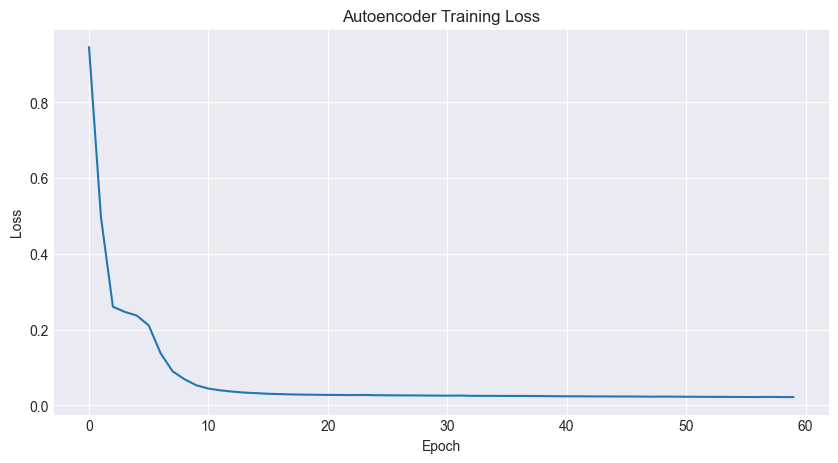


✅ AUTOENCODER - تم الانتهاء بنجاح


In [21]:
# ============================================
# FORCE CPU - نفس الكود الأصلي اللي كان شغال
# ============================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# تحميل البيانات
folder_path = r"C:\Users\ULTRA\Desktop\ML_DATASET"
X = np.load(os.path.join(folder_path, "X_scaled.npy"))
print(f"X shape: {X.shape}")

X_tensor = torch.tensor(X, dtype=torch.float32)

# ============================================
# AutoEncoder (نفس architecture الأصلي)
# ============================================
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=3, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2),
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 3),
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# ============================================
# الإعدادات (زي ما عندك)
# ============================================
latent_dim = 2  # خليها 2 زي الأصل
batch_size = 256
epochs = 60

# إنشاء النموذج (على CPU)
device = torch.device("cpu")
ae = AutoEncoder(input_dim=X.shape[1], latent_dim=latent_dim).to(device)
loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(ae.parameters(), lr=0.001)

# ============================================
# التدريب (نفس الكود الأصلي)
# ============================================
losses = []

print(f"Training AutoEncoder (input={X.shape[1]}, latent={latent_dim})")
print("="*50)

for epoch in range(epochs):
    ae.train()
    total_loss = 0
    for (xb,) in loader:
        xb = xb.to(device)
        loss = F.mse_loss(ae(xb), xb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    epoch_loss = total_loss / len(X)
    losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.6f}")

# حفظ النموذج
torch.save(ae.state_dict(), os.path.join(folder_path, "autoencoder_model.pth"))
print("\n✅ Saved: autoencoder_model.pth")

# ============================================
# استخراج Latent Space (بنفس طريقة الكود الأصلي)
# ============================================
ae.eval()
with torch.no_grad():
    latent_features = []
    for (xb,) in loader:
        xb = xb.to(device)
        z = ae.encode(xb)  # باستخدام encode() نفس الكود الأصلي
        latent_features.append(z.cpu().numpy())
    
    latent_numpy = np.concatenate(latent_features, axis=0)

np.save(os.path.join(folder_path, "latent_features.npy"), latent_numpy)
print(f"✅ Latent features saved: {latent_numpy.shape}")

# رسم Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.grid(True)
plt.savefig(os.path.join(folder_path, "autoencoder_loss.png"), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*40)
print("✅ AUTOENCODER - تم الانتهاء بنجاح")
print("="*40)

## Extract Latent Features and Visualize

Saved: latent_features.npy | Shape: (24297, 2)


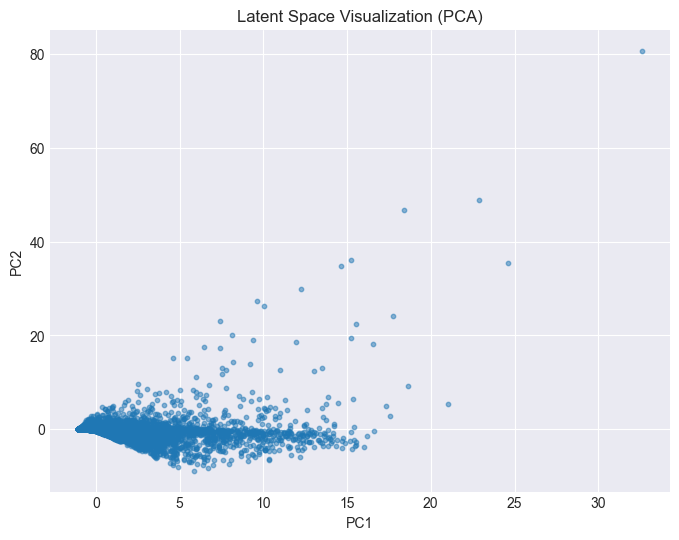

Saved: latent_space_visualization.png


In [23]:
ae.eval()
with torch.no_grad():
    latent = ae.encode(X_tensor.to(device)).cpu().numpy()

np.save(r"C:/Users/ULTRA/Desktop/ML_DATASET/latent_features.npy", latent)
print(f"Saved: latent_features.npy | Shape: {latent.shape}")

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent)

plt.figure(figsize=(8, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], s=10, alpha=0.5)
plt.title("Latent Space Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig(r"C:/Users/ULTRA\Desktop/ML_DATASET/latent_space_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: latent_space_visualization.png")

## K-Means on Latent Space

In [24]:
n_clusters = 2

kmeans_latent = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
latent_labels = kmeans_latent.fit_predict(latent)

silhouette_latent = silhouette_score(latent, latent_labels)
print(f"K-Means on Latent Space - Silhouette: {silhouette_latent:.4f}")

K-Means on Latent Space - Silhouette: 0.8371


# IDEC

In [25]:
# Cell 8: DEC Class
class DEC(nn.Module):
    def __init__(self, encoder, n_clusters, latent_dim):
        super().__init__()
        self.encoder = encoder
        self.cluster_centers = nn.Parameter(torch.randn(n_clusters, latent_dim))

    def soft_assign(self, z):
        diff = z.unsqueeze(1) - self.cluster_centers.unsqueeze(0)
        sq_dist = torch.sum(diff ** 2, dim=2)
        q = 1.0 / (1.0 + sq_dist)
        return q / torch.sum(q, dim=1, keepdim=True)

    def forward(self, x):
        z = self.encoder(x)
        return z, self.soft_assign(z)

def target_distribution(q):
    p = (q ** 2) / torch.sum(q, dim=0, keepdim=True)
    return p / torch.sum(p, dim=1, keepdim=True)

## Train IDEC

In [27]:
class IndexedTensorDataset(TensorDataset):
    def __getitem__(self, index):
        return self.tensors[0][index], index

# Use the actual latent dimension from the autoencoder output
correct_latent_dim = latent.shape[1]
dec = DEC(ae.encoder, n_clusters=n_clusters, latent_dim=correct_latent_dim).to(device)

kmeans_init = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_init.fit(latent)
with torch.no_grad():
    dec.cluster_centers.copy_(torch.tensor(kmeans_init.cluster_centers_))

loader_dec = DataLoader(IndexedTensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(dec.parameters(), lr=0.001)

print("\nTraining DEC...")
gamma = 0.1  
recon_weight = 1.0  # reconstruction loss weight

for epoch in range(50):
    dec.eval()
    with torch.no_grad():
        _, q_all = dec(X_tensor.to(device))
        p_all = target_distribution(q_all)

    dec.train()
    total_loss = 0
    for xb, indices in loader_dec: # Corrected to receive indices
        xb = xb.to(device)
        z_batch, q_batch = dec(xb)
        x_hat = ae.decoder(z_batch)

        # Select corresponding p values for the batch
        p_batch = p_all[indices].to(device)
        kl_loss = F.kl_div(torch.log(q_batch + 1e-10), p_batch, reduction="batchmean")
        recon_loss = F.mse_loss(x_hat, xb)
        loss = gamma * kl_loss + recon_weight * recon_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Combined Loss: {total_loss/len(X):.6f}") # Corrected epoch range and loss name

dec.eval()
with torch.no_grad():
    _, q_final = dec(X_tensor.to(device))
    dec_labels = torch.argmax(q_final, dim=1).cpu().numpy()

np.save(os.path.join(folder_path, "dec_labels.npy"), dec_labels)

print("\nSaved: dec_labels.npy")

silhouette_dec = silhouette_score(latent, dec_labels)
print(f"DEC Silhouette Score: {silhouette_dec:.4f}")


Training DEC...
Epoch 10/50 | Combined Loss: 0.024925
Epoch 20/50 | Combined Loss: 0.024986
Epoch 30/50 | Combined Loss: 0.025343
Epoch 40/50 | Combined Loss: 0.025539
Epoch 50/50 | Combined Loss: 0.025917

Saved: dec_labels.npy
DEC Silhouette Score: 0.7402


# Comparison Table (IDEC vs K-Means)

In [29]:
kmeans_original = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
original_labels = kmeans_original.fit_predict(X)
silhouette_original = silhouette_score(X, original_labels)

comparison = pd.DataFrame({
    "Method": ["K-Means (Original)", "K-Means (Latent)", "DEC"],
    "Silhouette Score": [silhouette_original, silhouette_latent, silhouette_dec]
})

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison.to_string(index=False))
print("="*50)

comparison.to_csv(os.path.join(folder_path, "dec_vs_kmeans_comparison.csv"), index=False)
print("\nSaved: dec_vs_kmeans_comparison.csv")


MODEL COMPARISON
            Method  Silhouette Score
K-Means (Original)          0.826338
  K-Means (Latent)          0.837129
               DEC          0.740154

Saved: dec_vs_kmeans_comparison.csv


## Output Files Summary

In [ ]:
print("\n" + "="*50)
print("OUTPUT FILES")
print("="*50)

files = {
    "autoencoder_model.pth": "Trained AutoEncoder model",
    "latent_features.npy": "Latent space features",
    "dec_labels.npy": "DEC cluster labels",
    "autoencoder_loss.png": "Loss curve plot",
    "latent_space_visualization.png": "Latent space PCA visualization",
    "dec_vs_kmeans_comparison.csv": "Comparison table"
}


base_path = r"C:/Users/ULTRA/Desktop/ML_DATASET"

for filename, description in files.items():
    filepath = os.path.join(base_path, filename)
    if os.path.exists(filepath):
        print(f"[OK] {filename} - {description}")
    else:
        print(f"[MISSING] {filename} - {description}")

print("\nAll tasks completed!")


OUTPUT FILES
[OK] autoencoder_model.pth - Trained AutoEncoder model
[OK] latent_features.npy - Latent space features
[OK] dec_labels.npy - DEC cluster labels
[OK] autoencoder_loss.png - Loss curve plot
[OK] latent_space_visualization.png - Latent space PCA visualization
[OK] dec_vs_kmeans_comparison.csv - Comparison table

All tasks completed!


X_scaled shape: (24297, 3)
DataFrame shape: (24297, 24)
Latent features shape: (24297, 2)
KMeans run on latent features
Cluster labels shape: (24297,)
Unique clusters: [0 1]

1. SOM - Self Organizing Map


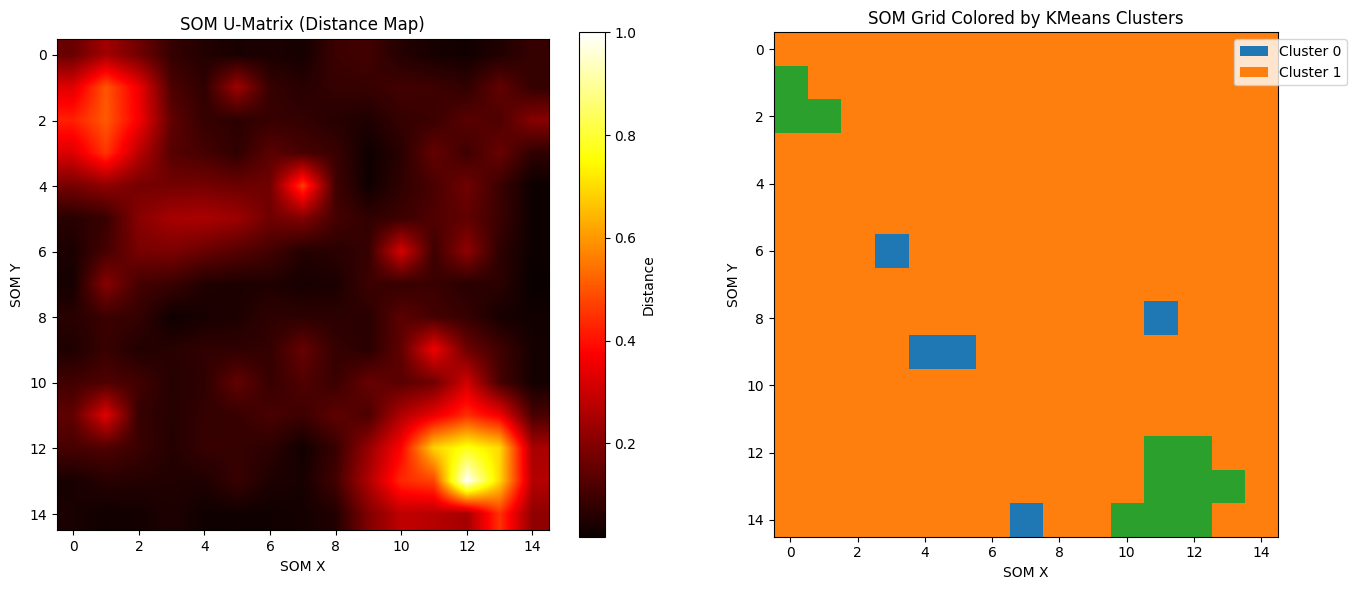

✅ Saved: som_umatrix_grid.png

2. PCA & t-SNE Visualizations


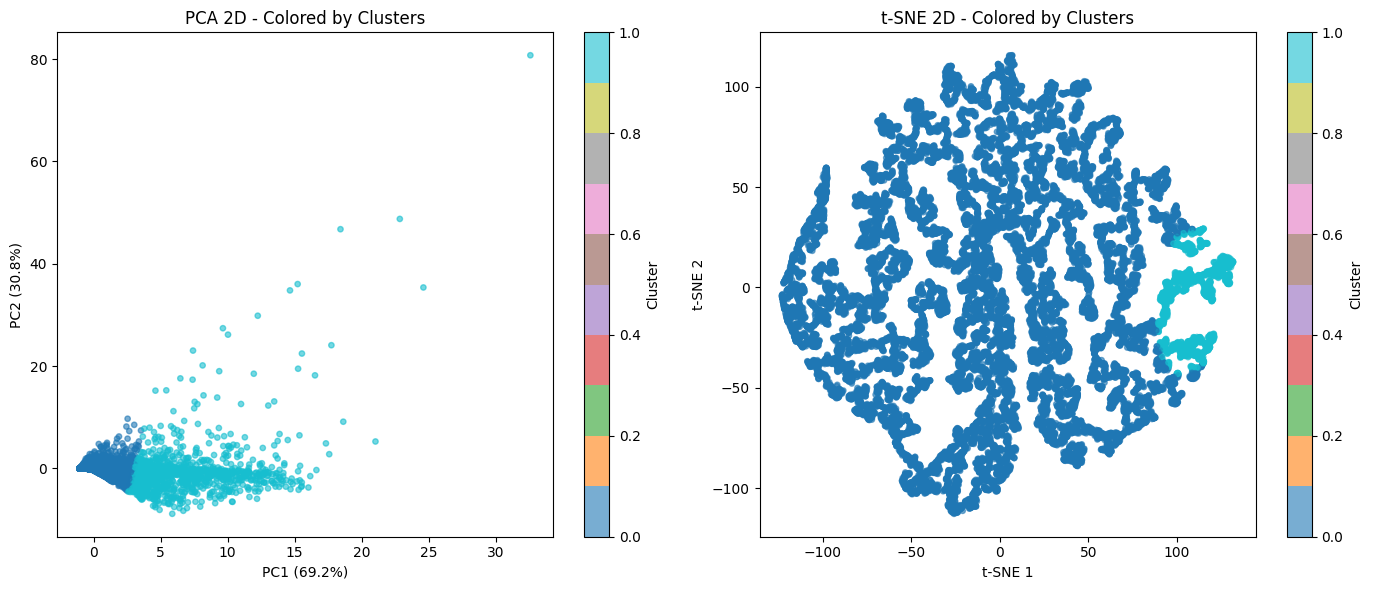

✅ Saved: pca_tsne_clusters.png


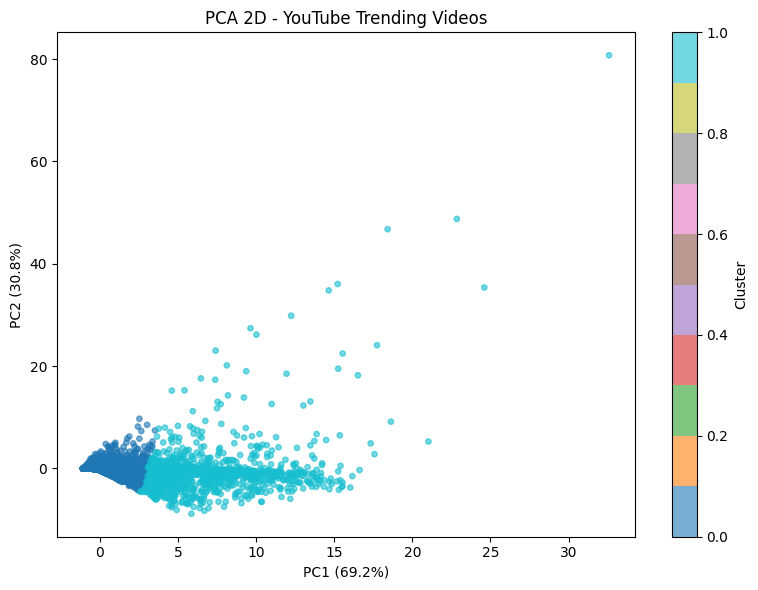

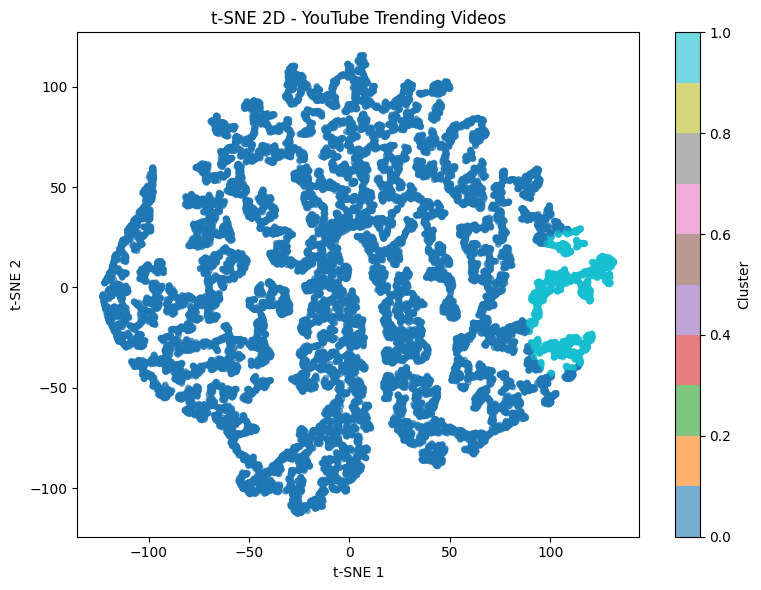

✅ Saved: pca_2d.png, tsne_2d.png

3. Country Comparison - Stacked Bar Chart


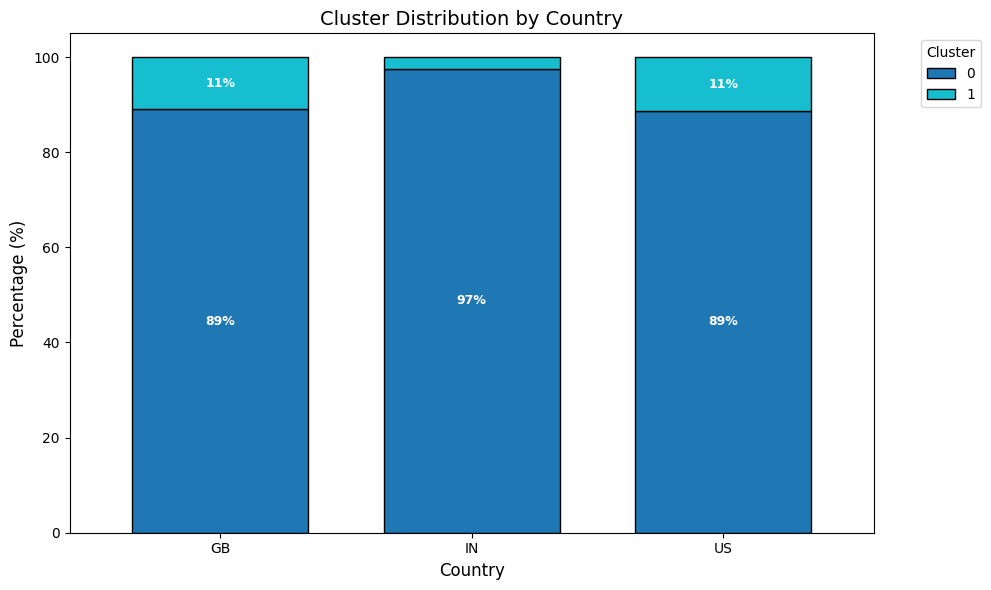


📊 Country Distribution (Absolute counts):
col_0        0    1
country            
GB        1924  238
IN       15546  407
US        5480  702

📊 Country Distribution (Percentages):
col_0       0     1
country            
GB       89.0  11.0
IN       97.4   2.6
US       88.6  11.4
✅ Saved: country_cluster_distribution.png

4. Anomaly Detection
Detected anomalies: 1215 out of 24297 (5.00%)


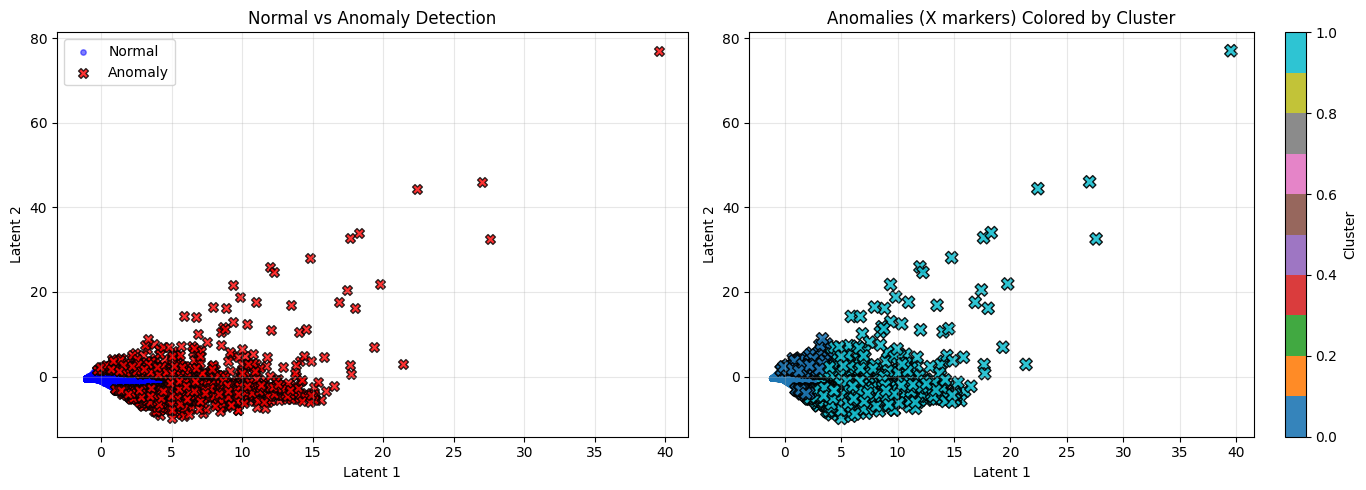

✅ Saved: anomaly_detection.png


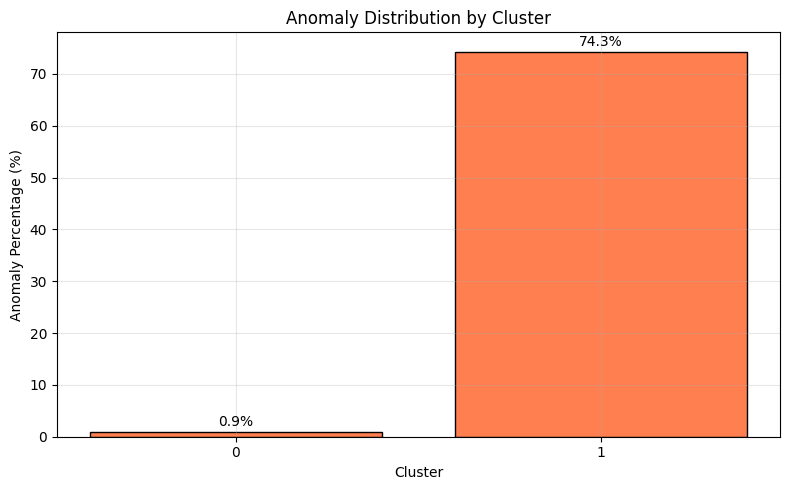

✅ Saved: anomaly_by_cluster.png

SUMMARY - PERSON 4 COMPLETED

📊 DATA SUMMARY:
- Total videos: 24297
- Features used: 2
- Clusters: 2
- Anomalies detected: 1215 (5.00%)

📁 OUTPUT FILES GENERATED:
1. som_umatrix_grid.png - SOM visualization
2. pca_tsne_clusters.png - PCA & t-SNE combined
3. pca_2d.png - PCA 2D plot
4. tsne_2d.png - t-SNE 2D plot
5. country_cluster_distribution.png - Country comparison
6. anomaly_detection.png - Anomaly scatter plots
7. anomaly_by_cluster.png - Anomaly percentage by cluster

✅ All tasks completed successfully!



In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. LOAD DATA
# ============================================
folder_path = r"C:/Users/ULTRA/Desktop/ML_DATASET"

# Load scaled data
X_scaled = np.load(os.path.join(folder_path, "X_scaled.npy"))
print(f"X_scaled shape: {X_scaled.shape}")

# Load final data with clusters (from Person 2)
df = pd.read_csv(os.path.join(folder_path, "final_data.csv"))
print(f"DataFrame shape: {df.shape}")

# Load latent features from Person 3 (Autoencoder)
try:
    latent_features = np.load(os.path.join(folder_path, "latent_features.npy"))
    print(f"Latent features shape: {latent_features.shape}")
    use_latent = True
except:
    print("Latent features not found, using original features")
    latent_features = X_scaled
    use_latent = False

# Get cluster labels (use KMeans from original data or latent)
if 'kmeans_cluster' in df.columns:
    cluster_labels = df['kmeans_cluster'].values
    print("Using kmeans_cluster from dataframe")
else:
    # If no cluster labels, run KMeans
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(latent_features)
    df['kmeans_cluster'] = cluster_labels
    print("KMeans run on latent features")

print(f"Cluster labels shape: {cluster_labels.shape}")
print(f"Unique clusters: {np.unique(cluster_labels)}")

# ============================================
# 2. SOM (Self Organizing Map)
# ============================================
try:
    from minisom import MiniSom
    print("\n" + "="*50)
    print("1. SOM - Self Organizing Map")
    print("="*50)
    
    # Normalize data for SOM
    from sklearn.preprocessing import MinMaxScaler
    scaler_som = MinMaxScaler()
    data_som = scaler_som.fit_transform(latent_features)
    
    # SOM parameters
    som_size = (15, 15)
    som = MiniSom(som_size[0], som_size[1], data_som.shape[1], sigma=1.0, learning_rate=0.5)
    som.random_weights_init(data_som)
    som.train_random(data_som, 500)
    
    # U-Matrix (distance map)
    u_matrix = som.distance_map()
    
    # Find winner neurons for each sample
    winner_coordinates = np.array([som.winner(x) for x in data_som])
    
    # Assign KMeans clusters to SOM neurons
    unique_neurons = np.unique(winner_coordinates, axis=0)
    neuron_labels = {}
    
    for neuron in unique_neurons:
        neuron_mask = (winner_coordinates == neuron).all(axis=1)
        if neuron_mask.any():
            neuron_clusters = cluster_labels[neuron_mask]
            neuron_labels[tuple(neuron)] = np.bincount(neuron_clusters).argmax()
    
    # Create SOM grid
    som_grid = np.full(som_size, -1)
    for (x, y), label in neuron_labels.items():
        som_grid[x, y] = label
    
    # Plot U-Matrix and SOM Grid
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # U-Matrix
    im1 = axes[0].imshow(u_matrix, cmap='hot', interpolation='bilinear')
    axes[0].set_title('SOM U-Matrix (Distance Map)')
    axes[0].set_xlabel('SOM X')
    axes[0].set_ylabel('SOM Y')
    plt.colorbar(im1, ax=axes[0], label='Distance')
    
    # SOM Grid with clusters
    im2 = axes[1].imshow(som_grid, cmap='tab10', interpolation='nearest', vmin=-1, vmax=9)
    axes[1].set_title('SOM Grid Colored by KMeans Clusters')
    axes[1].set_xlabel('SOM X')
    axes[1].set_ylabel('SOM Y')
    
    # Custom legend
    unique_labels = np.unique(som_grid)
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    patches = [plt.Rectangle((0,0),1,1, facecolor=colors[l%10]) for l in unique_labels if l != -1]
    axes[1].legend(patches, [f'Cluster {int(l)}' for l in unique_labels if l != -1], 
                   loc='upper right', bbox_to_anchor=(1.15, 1))
    
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, "som_umatrix_grid.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: som_umatrix_grid.png")
    
except Exception as e:
    print(f"SOM skipped: {e}")

# ============================================
# 3. PCA & t-SNE Visualizations
# ============================================
print("\n" + "="*50)
print("2. PCA & t-SNE Visualizations")
print("="*50)

# PCA
pca = PCA(n_components=2, random_state=42)
data_pca = pca.fit_transform(latent_features)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
data_tsne = tsne.fit_transform(latent_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA Plot
scatter1 = axes[0].scatter(data_pca[:, 0], data_pca[:, 1], 
                            c=cluster_labels, cmap='tab10', alpha=0.6, s=15)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'PCA 2D - Colored by Clusters')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# t-SNE Plot
scatter2 = axes[1].scatter(data_tsne[:, 0], data_tsne[:, 1], 
                            c=cluster_labels, cmap='tab10', alpha=0.6, s=15)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE 2D - Colored by Clusters')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "pca_tsne_clusters.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pca_tsne_clusters.png")

# Also save separate versions if needed
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(data_pca[:, 0], data_pca[:, 1], 
                      c=cluster_labels, cmap='tab10', alpha=0.6, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA 2D - YouTube Trending Videos')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "pca_2d.png"), dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(data_tsne[:, 0], data_tsne[:, 1], 
                      c=cluster_labels, cmap='tab10', alpha=0.6, s=15)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE 2D - YouTube Trending Videos')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "tsne_2d.png"), dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: pca_2d.png, tsne_2d.png")

# ============================================
# 4. Country Comparison (Stacked Bar Chart)
# ============================================
print("\n" + "="*50)
print("3. Country Comparison - Stacked Bar Chart")
print("="*50)

if 'country' in df.columns:
    # Create cross-tabulation
    country_cluster = pd.crosstab(df['country'], cluster_labels)
    
    # Normalize to percentages
    country_cluster_pct = country_cluster.div(country_cluster.sum(axis=1), axis=0) * 100
    
    # Plot stacked bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot stacked bars
    country_cluster_pct.plot(kind='bar', stacked=True, ax=ax, 
                              colormap='tab10', edgecolor='black', width=0.7)
    
    ax.set_xlabel('Country', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title('Cluster Distribution by Country', fontsize=14)
    ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Add percentage labels on bars
    for i, (country, row) in enumerate(country_cluster_pct.iterrows()):
        bottom = 0
        for cluster, pct in row.items():
            if pct > 5:  # Only show if > 5%
                ax.text(i, bottom + pct/2, f'{pct:.0f}%', 
                        ha='center', va='center', fontsize=9, color='white', fontweight='bold')
            bottom += pct
    
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, "country_cluster_distribution.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Country Distribution (Absolute counts):")
    print(country_cluster)
    print("\n📊 Country Distribution (Percentages):")
    print(country_cluster_pct.round(1))
    print("✅ Saved: country_cluster_distribution.png")
else:
    print("⚠️ 'country' column not found in dataframe")

# ============================================
# 5. Anomaly Detection
# ============================================
print("\n" + "="*50)
print("4. Anomaly Detection")
print("="*50)

# Use Isolation Forest for anomaly detection
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_pred = iso_forest.fit_predict(latent_features)
anomalies = (anomaly_pred == -1)
print(f"Detected anomalies: {anomalies.sum()} out of {len(anomalies)} ({anomalies.sum()/len(anomalies)*100:.2f}%)")

# Use PCA for visualization (or original if latent is 2D)
if latent_features.shape[1] > 2:
    pca_viz = PCA(n_components=2, random_state=42)
    viz_data = pca_viz.fit_transform(latent_features)
    x_label, y_label = 'PC1', 'PC2'
else:
    viz_data = latent_features
    x_label, y_label = 'Latent 1', 'Latent 2'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Normal vs Anomaly
axes[0].scatter(viz_data[~anomalies, 0], viz_data[~anomalies, 1], 
                 c='blue', label='Normal', alpha=0.5, s=15)
axes[0].scatter(viz_data[anomalies, 0], viz_data[anomalies, 1], 
                 c='red', label='Anomaly', alpha=0.8, s=50, marker='X', edgecolors='black')
axes[0].set_xlabel(x_label)
axes[0].set_ylabel(y_label)
axes[0].set_title('Normal vs Anomaly Detection')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Anomalies colored by cluster
normal_labels = cluster_labels[~anomalies]
anomaly_labels = cluster_labels[anomalies]

axes[1].scatter(viz_data[~anomalies, 0], viz_data[~anomalies, 1], 
                 c=normal_labels, cmap='tab10', alpha=0.4, s=15)
scatter = axes[1].scatter(viz_data[anomalies, 0], viz_data[anomalies, 1], 
                           c=anomaly_labels, cmap='tab10', alpha=0.9, s=80, 
                           marker='X', edgecolors='black', linewidth=1)
axes[1].set_xlabel(x_label)
axes[1].set_ylabel(y_label)
axes[1].set_title('Anomalies (X markers) Colored by Cluster')
plt.colorbar(scatter, ax=axes[1], label='Cluster')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "anomaly_detection.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: anomaly_detection.png")

# Also create a separate anomaly distribution plot
fig, ax = plt.subplots(figsize=(8, 5))
cluster_anomaly_counts = []
for c in sorted(np.unique(cluster_labels)):
    cluster_mask = (cluster_labels == c)
    anomaly_count = anomalies[cluster_mask].sum()
    total_count = cluster_mask.sum()
    cluster_anomaly_counts.append({
        'Cluster': c,
        'Anomalies': anomaly_count,
        'Total': total_count,
        'Percentage': anomaly_count / total_count * 100
    })

anomaly_df = pd.DataFrame(cluster_anomaly_counts)
bars = ax.bar(anomaly_df['Cluster'].astype(str), anomaly_df['Percentage'], 
              color='coral', edgecolor='black')
ax.set_xlabel('Cluster')
ax.set_ylabel('Anomaly Percentage (%)')
ax.set_title('Anomaly Distribution by Cluster')
ax.grid(True, alpha=0.3)

for bar, pct in zip(bars, anomaly_df['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "anomaly_by_cluster.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: anomaly_by_cluster.png")

# ============================================
# 6. Summary Report
# ============================================
print("\n" + "="*50)
print("SUMMARY - PERSON 4 COMPLETED")
print("="*50)
print(f"""
📊 DATA SUMMARY:
- Total videos: {len(df)}
- Features used: {latent_features.shape[1]}
- Clusters: {len(np.unique(cluster_labels))}
- Anomalies detected: {anomalies.sum()} ({anomalies.sum()/len(anomalies)*100:.2f}%)

📁 OUTPUT FILES GENERATED:
1. som_umatrix_grid.png - SOM visualization
2. pca_tsne_clusters.png - PCA & t-SNE combined
3. pca_2d.png - PCA 2D plot
4. tsne_2d.png - t-SNE 2D plot
5. country_cluster_distribution.png - Country comparison
6. anomaly_detection.png - Anomaly scatter plots
7. anomaly_by_cluster.png - Anomaly percentage by cluster

✅ All tasks completed successfully!
""")

YOUTUBE VIRAL PREDICTION

[1] Loading data...
Data shape: (24297, 24)
Features shape: (24297, 3)

[2] Creating viral target...
Viral threshold (80th percentile): 517,413 views
Viral videos: 4860 (20.0%)
Non-viral videos: 19437 (80.0%)

[3] Splitting data (70% train, 30% test)...
Train set: 17007 samples
Test set: 7290 samples

[4] Training KNN Classifier...
KNN Test Results:
  Accuracy:  0.9968
  F1-Score:  0.9921
  Precision: 0.9952
  Recall:    0.9890

[5] Training RBF SVM Classifier...
SVM Test Results:
  Accuracy:  0.9912
  F1-Score:  0.9785
  Precision: 0.9580
  Recall:    1.0000

[6] Model Comparison:
Metric          KNN             RBF SVM        
------------------------------------------------------------
Accuracy        0.9968         0.9912
F1-Score        0.9921         0.9785
Precision       0.9952         0.9580
Recall          0.9890         1.0000

 BEST MODEL: KNN with Accuracy = 0.9968

[7] Generating confusion matrices...
✓ Figure saved to 'visualizations/confusion_m

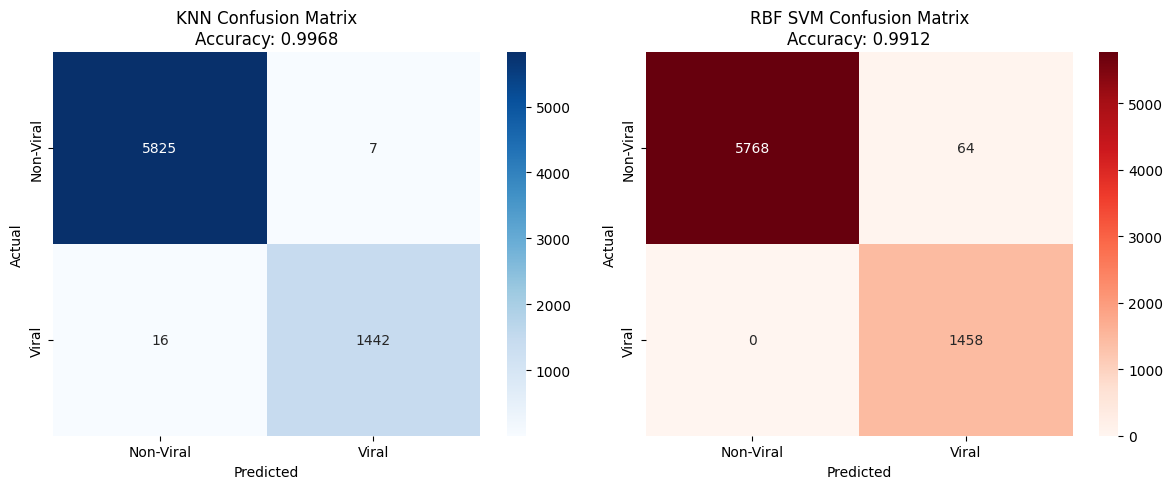


[8] Saving models and results...
✓ Models saved: 'knn_model.pkl', 'rbf_model.pkl'
✓ Results saved: 'viral_prediction_results.csv'

[9] Creating prediction function...
✓ Prediction function created

FINAL SUMMARY - Person 5 (Viral Prediction)

 KNN Model Accuracy:  99.68%
 RBF SVM Accuracy:    99.12%
 Best Model:          KNN (99.68%)

 Files Created:
   - knn_model.pkl
   - rbf_model.pkl
   - viral_prediction_results.csv
   - visualizations/confusion_matrices.png

 Configuration:
   - Viral threshold: Top 20% (517,413 views)
   - Train/Test split: 70/30
   - KNN: n_neighbors=5, weights='distance'
   - SVM: kernel='rbf', C=1.0, gamma='scale'



In [11]:
"""
Viral Prediction with KNN & RBF (SVM) - Simple & Clean Version
YouTube Trending Videos - Person 5 Task
"""

import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CREATE NECESSARY FOLDERS
# ============================================================================
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')
    print("✓ Created 'visualizations' folder")

print("="*80)
print("YOUTUBE VIRAL PREDICTION")
print("="*80)

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n[1] Loading data...")

df = pd.read_csv(r"C:\Users\ULTRA\Desktop\ML_DATASET\final_data.csv")
X = np.load(r"C:\Users\ULTRA\Desktop\ML_DATASET\X_scaled.npy")

print(f"Data shape: {df.shape}")
print(f"Features shape: {X.shape}")

# ============================================================================
# 2. CREATE VIRAL TARGET (Top 20% Views)
# ============================================================================
print("\n[2] Creating viral target...")

viral_threshold = df['views'].quantile(0.80)
print(f"Viral threshold (80th percentile): {viral_threshold:,.0f} views")

df['is_viral'] = (df['views'] >= viral_threshold).astype(int)

viral_count = df['is_viral'].sum()
total_count = len(df)
print(f"Viral videos: {viral_count} ({viral_count/total_count*100:.1f}%)")
print(f"Non-viral videos: {total_count - viral_count} ({(total_count-viral_count)/total_count*100:.1f}%)")

y = df['is_viral'].values

# ============================================================================
# 3. TRAIN-TEST SPLIT
# ============================================================================
print("\n[3] Splitting data (70% train, 30% test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ============================================================================
# 4. KNN MODEL
# ============================================================================
print("\n[4] Training KNN Classifier...")

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)

print(f"KNN Test Results:")
print(f"  Accuracy:  {knn_acc:.4f}")
print(f"  F1-Score:  {knn_f1:.4f}")
print(f"  Precision: {knn_precision:.4f}")
print(f"  Recall:    {knn_recall:.4f}")

# ============================================================================
# 5. RBF SVM MODEL
# ============================================================================
print("\n[5] Training RBF SVM Classifier...")

svm = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42, probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)

print(f"SVM Test Results:")
print(f"  Accuracy:  {svm_acc:.4f}")
print(f"  F1-Score:  {svm_f1:.4f}")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall:    {svm_recall:.4f}")

# ============================================================================
# 6. COMPARE RESULTS
# ============================================================================
print("\n[6] Model Comparison:")
print("="*60)
print(f"{'Metric':<15} {'KNN':<15} {'RBF SVM':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {knn_acc:.4f}{'':<8} {svm_acc:.4f}")
print(f"{'F1-Score':<15} {knn_f1:.4f}{'':<8} {svm_f1:.4f}")
print(f"{'Precision':<15} {knn_precision:.4f}{'':<8} {svm_precision:.4f}")
print(f"{'Recall':<15} {knn_recall:.4f}{'':<8} {svm_recall:.4f}")
print("="*60)

if knn_acc > svm_acc:
    best_model = 'KNN'
    best_accuracy = knn_acc
    best_model_obj = knn
else:
    best_model = 'RBF SVM'
    best_accuracy = svm_acc
    best_model_obj = svm

print(f"\n BEST MODEL: {best_model} with Accuracy = {best_accuracy:.4f}")

# ============================================================================
# 7. CONFUSION MATRICES
# ============================================================================
print("\n[7] Generating confusion matrices...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title(f'KNN Confusion Matrix\nAccuracy: {knn_acc:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Non-Viral', 'Viral'])
axes[0].set_yticklabels(['Non-Viral', 'Viral'])

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', ax=axes[1], cmap='Reds')
axes[1].set_title(f'RBF SVM Confusion Matrix\nAccuracy: {svm_acc:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Non-Viral', 'Viral'])
axes[1].set_yticklabels(['Non-Viral', 'Viral'])

plt.tight_layout()
plt.savefig('visualizations/confusion_matrices.png', dpi=150, bbox_inches='tight')
print("✓ Figure saved to 'visualizations/confusion_matrices.png'")
plt.show()

# ============================================================================
# 8. SAVE MODELS AND RESULTS
# ============================================================================
print("\n[8] Saving models and results...")

# Save models
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn, f)

with open('rbf_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

print("✓ Models saved: 'knn_model.pkl', 'rbf_model.pkl'")

# Save comparison results
results_df = pd.DataFrame({
    'Model': ['KNN', 'RBF SVM'],
    'Accuracy': [knn_acc, svm_acc],
    'F1_Score': [knn_f1, svm_f1],
    'Precision': [knn_precision, svm_precision],
    'Recall': [knn_recall, svm_recall]
})

results_df.to_csv('viral_prediction_results.csv', index=False)
print("✓ Results saved: 'viral_prediction_results.csv'")

# ============================================================================
# 9. PREDICTION FUNCTION
# ============================================================================
print("\n[9] Creating prediction function...")

def predict_viral(features, model='best'):
    """
    Predict if a video will be viral.
    
    Parameters:
    - features: numpy array of scaled features
    - model: 'knn', 'svm', or 'best'
    
    Returns:
    - prediction: 0 (non-viral) or 1 (viral)
    - probability: probability of being viral
    """
    if model == 'knn':
        pred = knn.predict(features)
        prob = knn.predict_proba(features)[:, 1]
    elif model == 'svm':
        pred = svm.predict(features)
        prob = svm.predict_proba(features)[:, 1]
    else:  # best
        pred = best_model_obj.predict(features)
        prob = best_model_obj.predict_proba(features)[:, 1]
    
    return pred, prob

print("✓ Prediction function created")

# ============================================================================
# 10. FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FINAL SUMMARY - Person 5 (Viral Prediction)")
print("="*80)
print(f"""
 KNN Model Accuracy:  {knn_acc*100:.2f}%
 RBF SVM Accuracy:    {svm_acc*100:.2f}%
 Best Model:          {best_model} ({best_accuracy*100:.2f}%)

 Files Created:
   - knn_model.pkl
   - rbf_model.pkl
   - viral_prediction_results.csv
   - visualizations/confusion_matrices.png

 Configuration:
   - Viral threshold: Top 20% ({viral_threshold:,.0f} views)
   - Train/Test split: 70/30
   - KNN: n_neighbors=5, weights='distance'
   - SVM: kernel='rbf', C=1.0, gamma='scale'
""")
print("="*80)

In [ ]:

y_train_pred = knn.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

test_acc = knn_results['accuracy']

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Difference: {train_acc - test_acc:.4f}")

Train Accuracy: 1.0000
Test Accuracy: 0.9970
Difference: 0.0030


In [12]:


print("\n" + "="*60)
print("OVERFITTING CHECK")
print("="*60)

# 1. Train vs Test Accuracy
y_train_pred_knn = knn.predict(X_train)
train_acc_knn = accuracy_score(y_train, y_train_pred_knn)

print(f"\nKNN:")
print(f"  Train Accuracy: {train_acc_knn:.4f}")
print(f"  Test Accuracy:  {knn_acc:.4f}")
print(f"  Difference:     {train_acc_knn - knn_acc:.4f}")

if (train_acc_knn - knn_acc) < 0.02:
    print("   No overfitting detected!")
else:
    print("   Possible overfitting - difference > 2%")


y_train_pred_svm = svm.predict(X_train)
train_acc_svm = accuracy_score(y_train, y_train_pred_svm)

print(f"\nSVM:")
print(f"  Train Accuracy: {train_acc_svm:.4f}")
print(f"  Test Accuracy:  {svm_acc:.4f}")
print(f"  Difference:     {train_acc_svm - svm_acc:.4f}")

if (train_acc_svm - svm_acc) < 0.02:
    print("   No overfitting detected!")
else:
    print("   Possible overfitting - difference > 2%")


OVERFITTING CHECK

KNN:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9968
  Difference:     0.0032
   No overfitting detected!

SVM:
  Train Accuracy: 0.9893
  Test Accuracy:  0.9912
  Difference:     -0.0019
   No overfitting detected!
